In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller



In [13]:
# Read in the processed dataset
file_path = '../data/processed/processed_data_pre_model.csv'
df = pd.read_csv(file_path)

C:\Users\sbout\AppData\Local\Temp\ipykernel_13632\955667600.py:3: DtypeWarning: Columns (46,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [3]:
df.describe()

,county_fips,median_listing_price_x,median_listing_price_mm_x,median_listing_price_yy_x,active_listing_count,active_listing_count_mm,active_listing_count_yy,median_days_on_market_x,median_days_on_market_mm_x,median_days_on_market_yy_x,...,U.S. 30 year FRM,30 year fees & points,U.S. 15 year FRM,15 year fees & points,U.S. 5/1 ARM,5/1 year fees & points,U.S. 5/1 ARM margin,30 year FRM / 5/1 ARM spread,month,highest_category
count,360053.00000,3.600280e+05,322557.000000,321231.000000,360053.000000,322486.000000,321071.000000,359710.000000,322246.000000,320783.000000,...,360053.000000,238692.000000,360053.000000,238692.000000,238692.000000,238692.000000,238692.000000,238692.000000,34156.000000,31047.000000
mean,30307.92485,2.703053e+05,0.017487,0.120064,292.939042,0.009125,0.078057,74.318448,0.046456,0.100056,...,4.844304,0.611065,4.172829,0.590817,3.358747,0.339297,2.750027,0.563095,9.271900,2.802364
std,15154.92739,2.194439e+05,1.059819,0.935075,867.790716,0.192785,0.773584,35.048294,0.433508,1.373417,...,1.495556,0.128521,1.441222,0.157097,0.657493,0.070461,0.007652,0.360221,0.863141,1.326533
min,1001.00000,1.000000e+00,-0.997100,-0.996800,0.000000,-1.000000,-1.000000,1.000000,-0.996700,-0.994800,...,2.684000,0.440000,2.145000,0.400000,2.422500,0.200000,2.737500,-0.237500,8.000000,1.000000
25%,18167.00000,1.499250e+05,-0.027600,-0.032100,26.000000,-0.073500,-0.225800,50.000000,-0.092500,-0.193500,...,3.616000,0.500000,3.027500,0.480000,2.888000,0.300000,2.747500,0.300000,9.000000,2.000000
50%,29153.00000,2.250000e+05,0.000000,0.056400,74.000000,0.000000,-0.017500,68.000000,0.044900,-0.014300,...,4.444000,0.550000,3.906000,0.520000,3.226000,0.325000,2.750000,0.642500,9.000000,3.000000
75%,45063.00000,3.300000e+05,0.035000,0.174500,226.000000,0.066700,0.242700,92.000000,0.164600,0.196700,...,6.428000,0.700000,5.682000,0.680000,3.695000,0.400000,2.750000,0.792000,10.000000,4.000000
max,56045.00000,1.300000e+07,570.319600,222.874900,23258.000000,32.500000,91.500000,365.000000,114.000000,266.000000,...,7.620000,0.900000,6.905000,1.150000,6.005000,0.500000,2.770000,1.287500,11.000000,5.000000


In [15]:
# Convert time column into true Datetime objects so Matplotlib can shade specific date
df['date'] = pd.to_datetime(df['date'].astype(str), format='%Y-%m-%d')

# Create a 'Region' column to split the dataset
df['Region'] = 'Rest of US'

# Change Region value to Florida for state_id = fl
df.loc[df['state'] == 'fl', 'Region'] = 'Florida' 

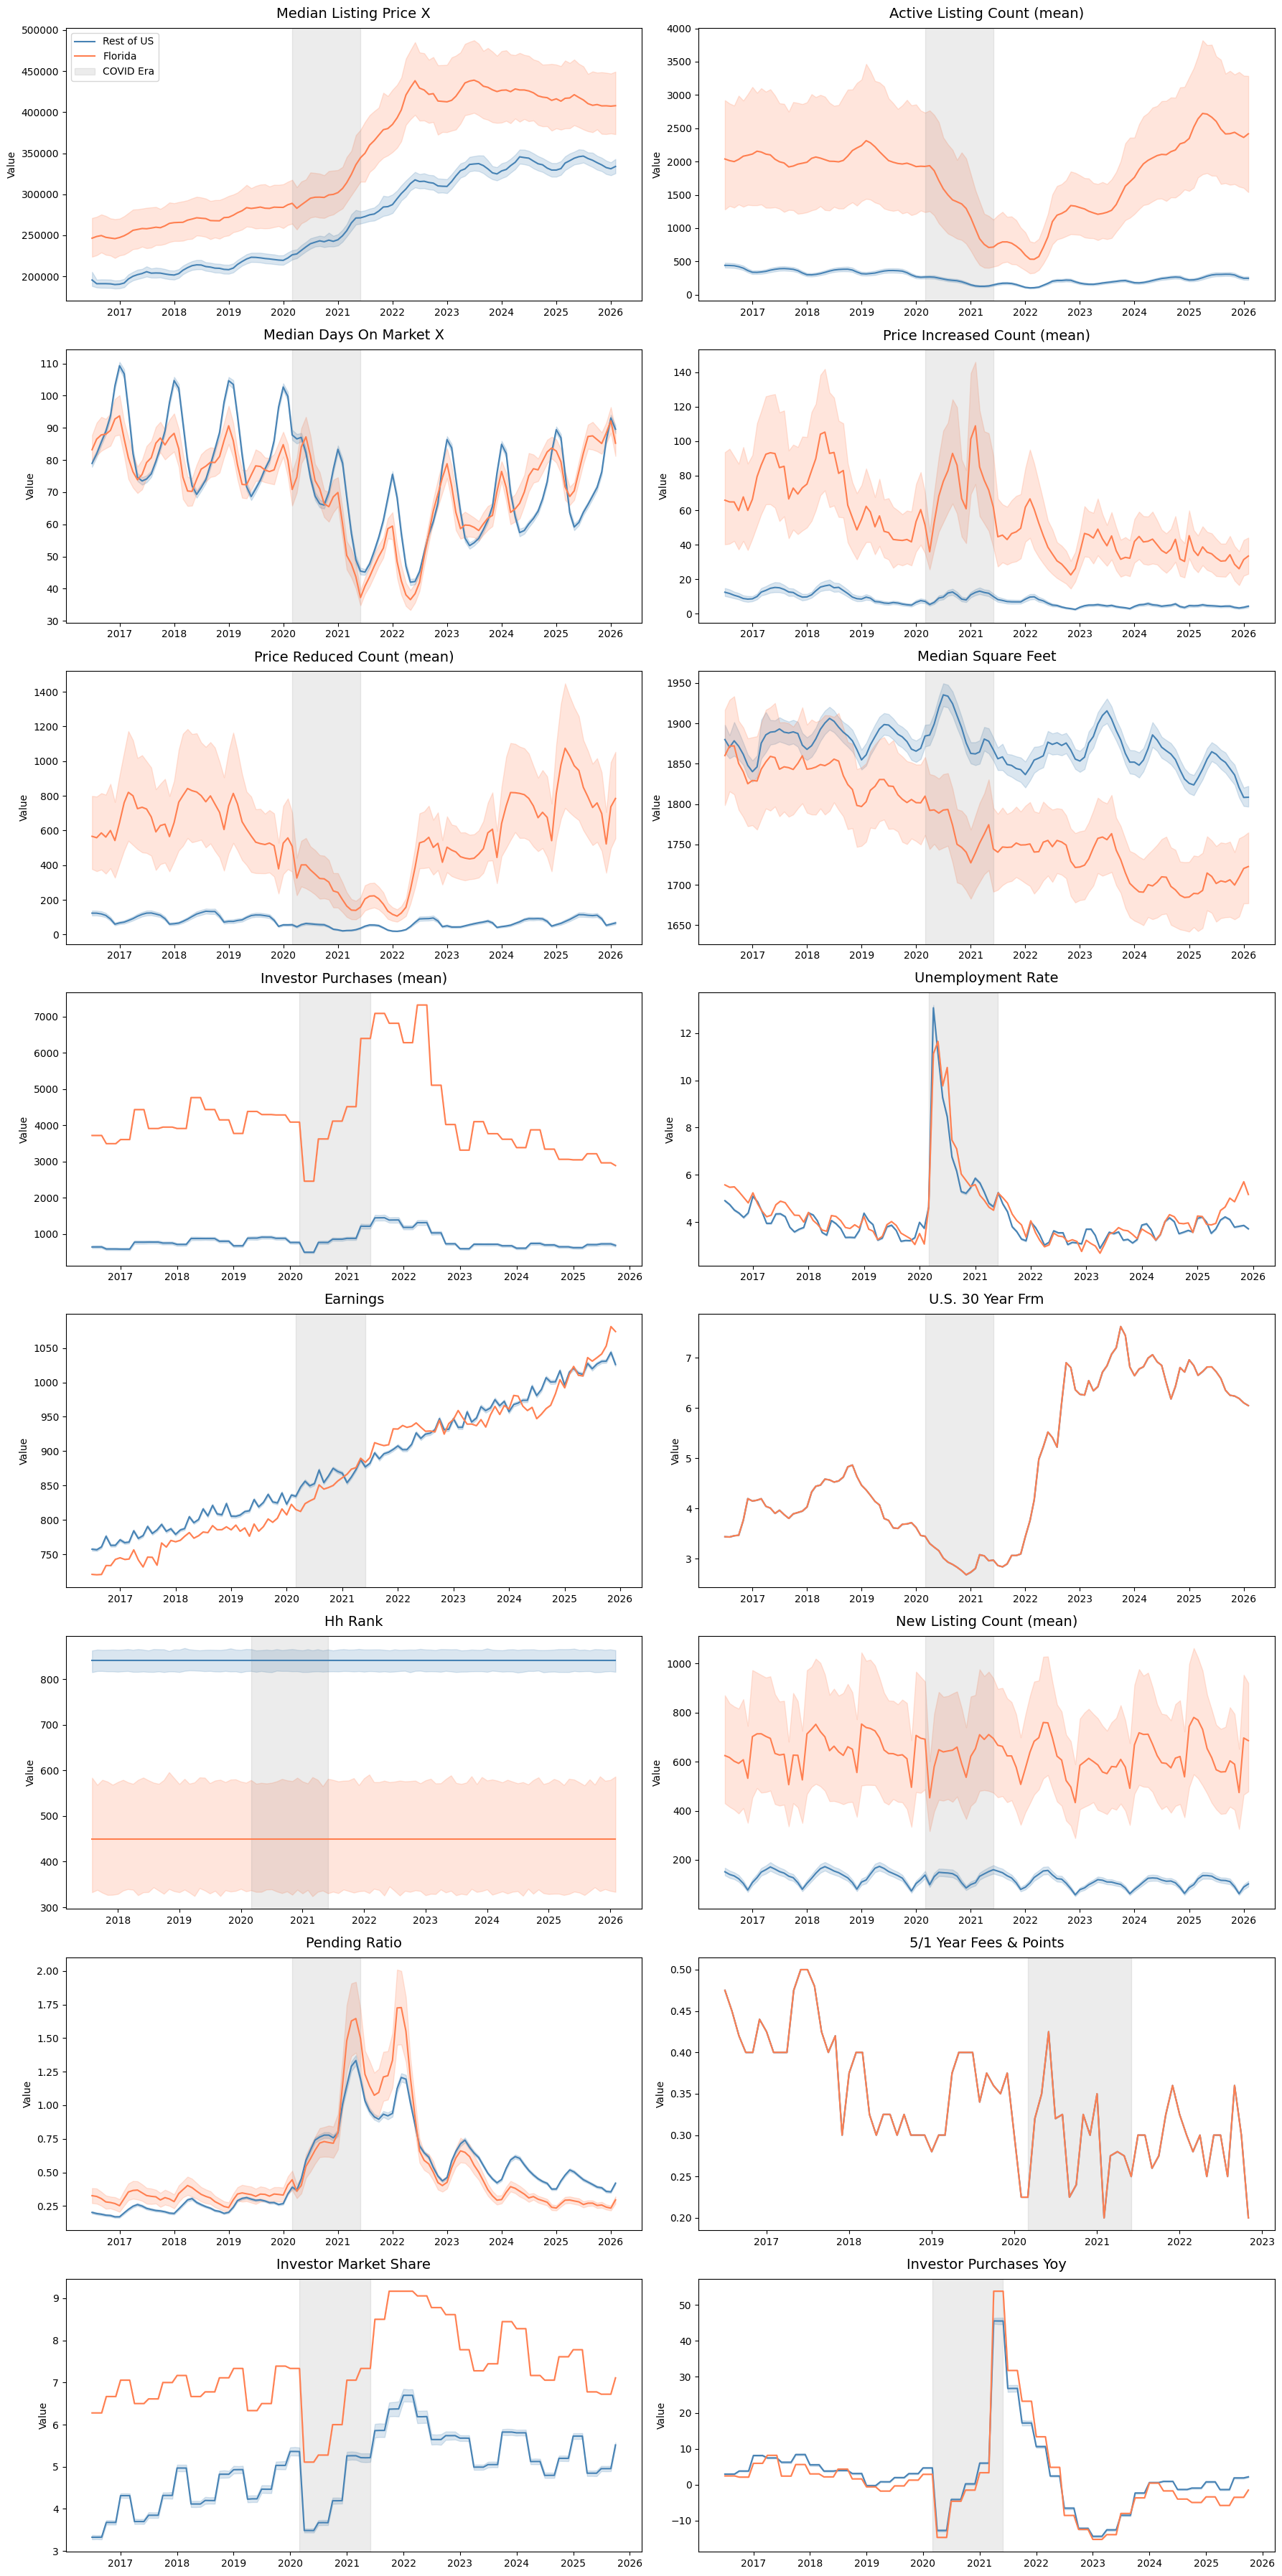

In [ ]:
# Select relevant features to plot

columns_to_plot = [
    'median_listing_price_x', 'active_listing_count', 'median_days_on_market_x', 
    'price_increased_count', 'price_reduced_count', 'median_square_feet',  
    'Investor Purchases', 'Unemployment_Rate', 'Earnings', 'U.S. 30 year FRM',
    'hh_rank', 'new_listing_count', 'pending_ratio', '5/1 year fees & points',
    'Investor Market Share', 'Investor Purchases YoY'
]

# Set up plot
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(18, 36))
axes = axes.flatten()

# Define COVID era shading boundaries (Year-Month-Day)
covid_start = pd.to_datetime('2020-03-01')
covid_end = pd.to_datetime('2021-05-31')

# The specific columns that need "(mean)" added to their title
mean_title_cols = [
    'active_listing_count', 
    'price_increased_count', 
    'price_reduced_count', 
    'new_listing_count', 
    'Investor Purchases'
]

# plot
for i, col in enumerate(columns_to_plot):
    if col in df.columns:
        # Plot both regions on the same axis (using the default mean estimator)
        sns.lineplot(
            data=df, x='date', y=col, hue='Region', 
            ax=axes[i], palette={'Florida': 'coral', 'Rest of US': 'steelblue'}
        )
        
        # Clean up the titles (e.g., changes 'median_listing_price_x' to 'Median Listing Price X')
        clean_title = col.replace('_', ' ').title()
        
        # APPEND "(mean)" IF IT IS A COUNT VARIABLE
        if col in mean_title_cols:
            clean_title += " (mean)"
            
        axes[i].set_title(clean_title, fontsize=14, pad=10)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Value')
        
        # Add the light shading for the COVID era
        axes[i].axvspan(covid_start, covid_end, color='gray', alpha=0.15)
        
        # Only keep the legend on the very first plot
        if i == 0:
            covid_patch = mpatches.Patch(color='gray', alpha=0.15, label='COVID Era')
            handles, labels = axes[i].get_legend_handles_labels()
            axes[i].legend(handles=handles + [covid_patch], loc='best')
        else:
            axes[i].get_legend().remove()
            
    else:
        axes[i].set_visible(False)
        print(f"Warning: Column '{col}' not found. Check capitalization!")

# Adjust the layout to keep it looking clean
plt.tight_layout()
plt.show()



C:\Users\sbout\AppData\Local\Temp\ipykernel_13632\1882337253.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['year_month'] = df2['date'].dt.to_period('M').astype(str)


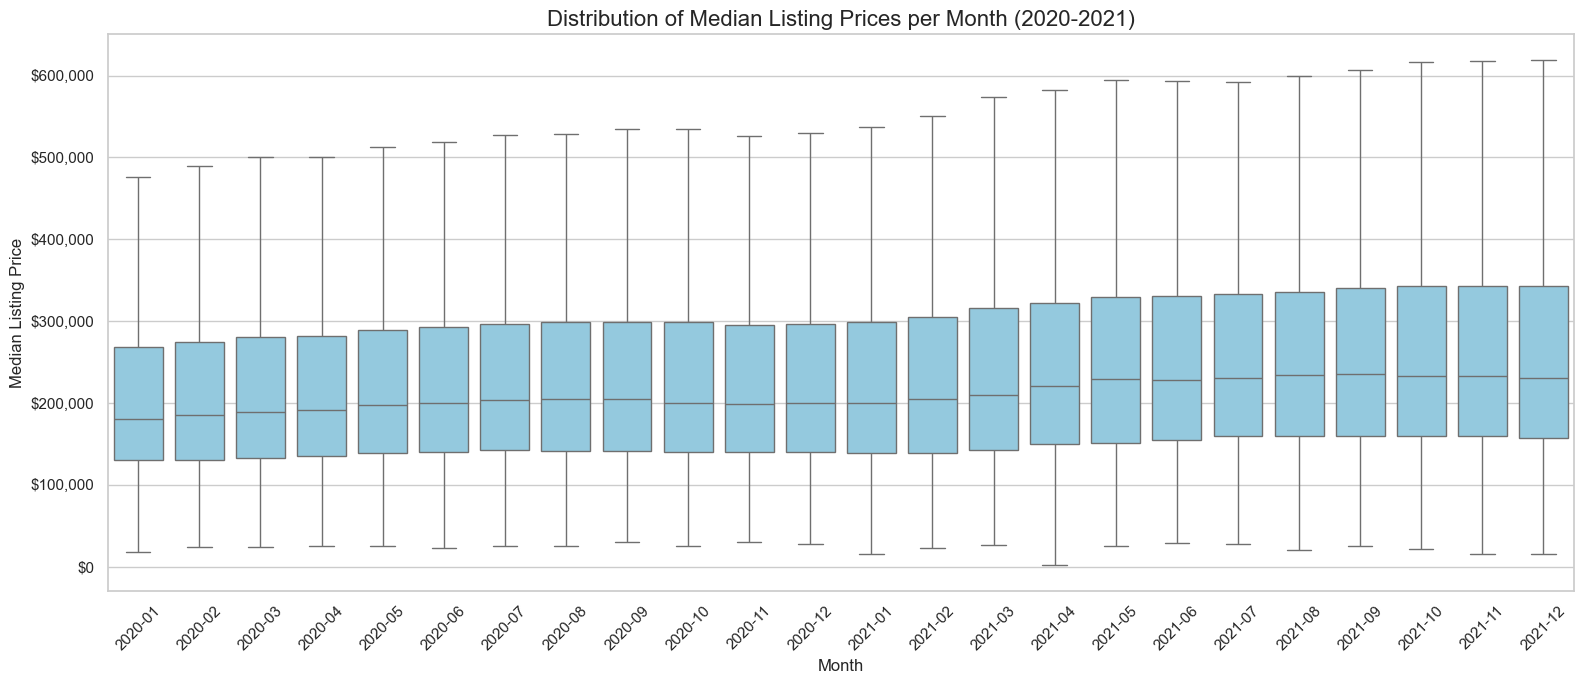

In [16]:
# filter out any missing prices
df = df.dropna(subset=['median_listing_price_x'])

# Extract Year-Month for grouping the X-axis labels (e.g., '2016-07')
df['year_month'] = df['date'].dt.to_period('M').astype(str)

# Filter for the specific years 2020 and 2021
df2 = df[(df['date'].dt.year >= 2020) & (df['date'].dt.year <= 2021)]

# Extract Year-Month for grouping the X-axis labels (e.g., '2020-07')
df2['year_month'] = df2['date'].dt.to_period('M').astype(str)

# Sort chronologically 
df2 = df2.sort_values('date')

# Create the Box Plot
plt.figure(figsize=(16, 7))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    data=df2, 
    x='year_month', 
    y='median_listing_price_x', 
    color='skyblue',
    showfliers=False
)
# Format the plot for readability
plt.title('Distribution of Median Listing Prices per Month (2020-2021)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Median Listing Price', fontsize=12)
# Rotate X-axis labels to 45 degrees
plt.xticks(rotation=45)
# Format Y-axis ticks as dollar amounts
formatter = FuncFormatter(lambda x, pos: f'${x:,.0f}')
ax.yaxis.set_major_formatter(formatter)
# Adjust layout
plt.tight_layout()
plt.show()


--- Augmented Dickey-Fuller Test: Whole US ---
ADF Statistic: -2.3664
p-value: 0.1515
=> Fail to reject the null hypothesis: The series is Non-Stationary (has a unit root).

--- Augmented Dickey-Fuller Test: Florida ---
ADF Statistic: -1.0623
p-value: 0.7299
=> Fail to reject the null hypothesis: The series is Non-Stationary (has a unit root).

--- Augmented Dickey-Fuller Test: Rest of US (excluding FL) ---
ADF Statistic: -2.5903
p-value: 0.0950
=> Fail to reject the null hypothesis: The series is Non-Stationary (has a unit root).



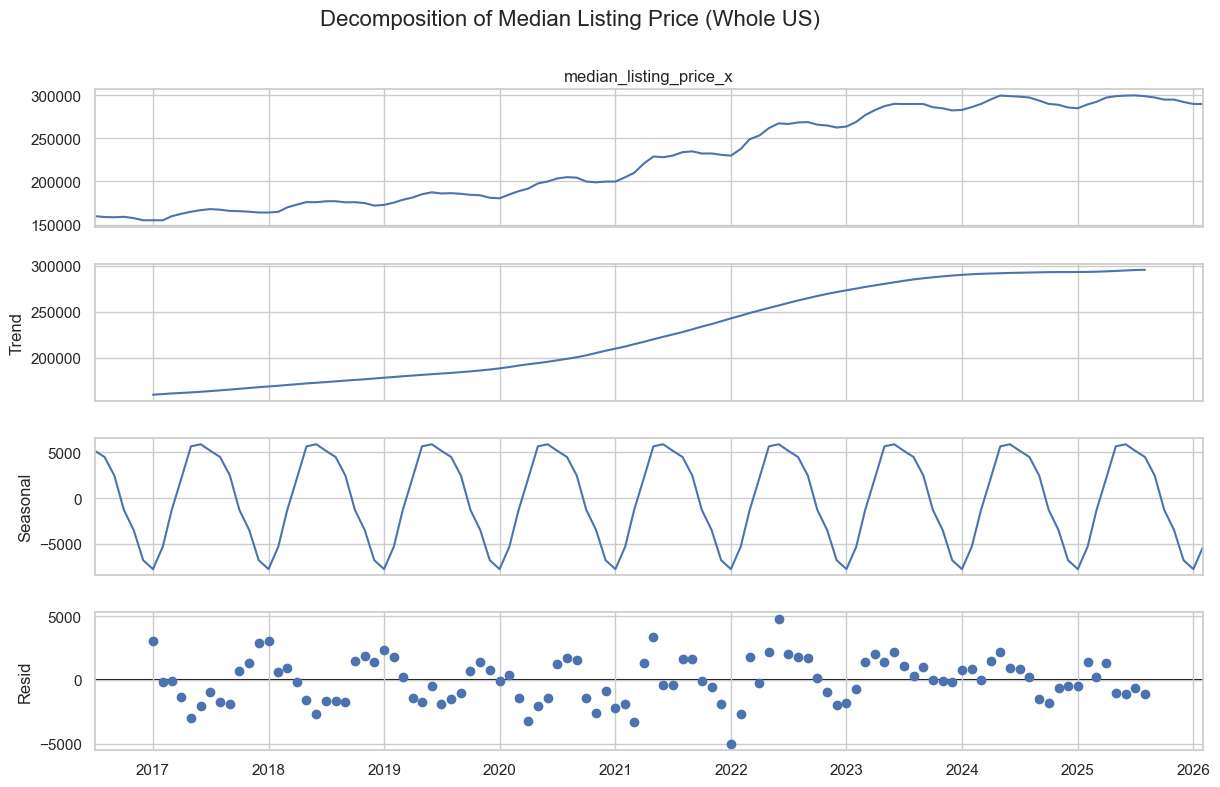

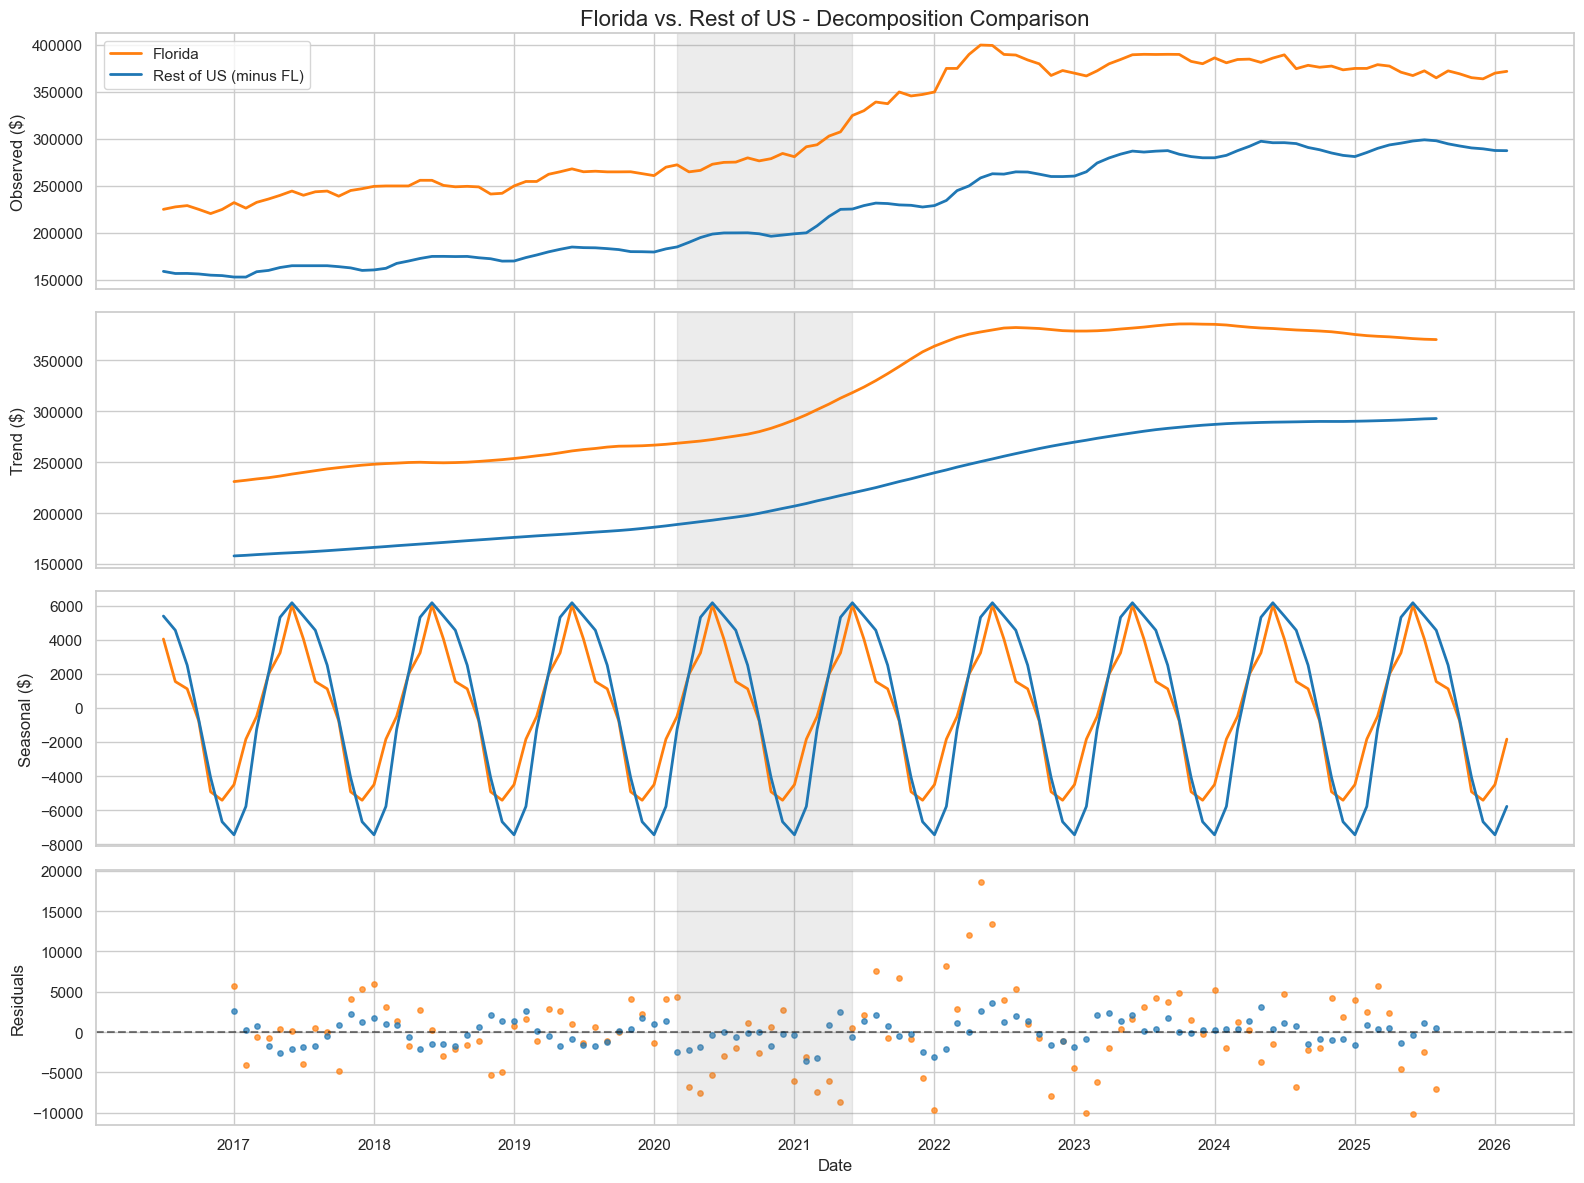

In [22]:
# Standardize state strings to lowercase to ensure clean filtering
df['state'] = df['state'].astype(str).str.lower()

# Helper function to generate a continuous monthly median series
def get_monthly_median_series(subset):
    # Group by date and calculate median of median listings for the selected region
    s = subset.groupby('date')['median_listing_price_x'].median()
    # Ensure a rigid Month-Start frequency (required by `seasonal_decompose`)
    s = s.sort_index().resample('MS').mean() 
    s = s.interpolate() # Safety interpolator in case any month was completely unrecorded
    return s
us_series   = get_monthly_median_series(df)
fl_series   = get_monthly_median_series(df[df['state'] == 'fl'])
rest_series = get_monthly_median_series(df[df['state'] != 'fl'])

# Stationarity Checks (Augmented Dickey-Fuller Test)
def print_adf_test(series, title):
    print(f"--- Augmented Dickey-Fuller Test: {title} ---")
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    
    if result[1] <= 0.05:
        print("=> Reject the null hypothesis: The series is Stationary.\n")
    else:
        print("=> Fail to reject the null hypothesis: The series is Non-Stationary (has a unit root).\n")
print_adf_test(us_series, "Whole US")
print_adf_test(fl_series, "Florida")
print_adf_test(rest_series, "Rest of US (excluding FL)")

# Timeseries Decomposition
# Period is set to 12 representing 12 months in a yearly cycle
period = 12 
dec_us   = seasonal_decompose(us_series, model='additive', period=period)
dec_fl   = seasonal_decompose(fl_series, model='additive', period=period)
dec_rest = seasonal_decompose(rest_series, model='additive', period=period)

# Plotting
# Whole US Decomposition 
fig_us = dec_us.plot()
fig_us.set_size_inches(14, 8)
fig_us.suptitle('Decomposition of Median Listing Price (Whole US)', y=1.02, fontsize=16)
plt.show()

# Florida vs Rest of US (Minus FL) 
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
sns.set_theme(style="whitegrid")
# Brand colors for visual clarity
color_fl = '#ff7f0e' # Orange
color_rest = '#1f77b4' # Blue
# Panel 1: Observed
axes[0].plot(dec_fl.observed, label='Florida', color=color_fl, linewidth=2)
axes[0].plot(dec_rest.observed, label='Rest of US (minus FL)', color=color_rest, linewidth=2)
axes[0].set_ylabel('Observed ($)')
axes[0].set_title('Florida vs. Rest of US - Decomposition Comparison', fontsize=16)
axes[0].legend(loc='upper left')
# Panel 2: Trend
axes[1].plot(dec_fl.trend, label='Florida', color=color_fl, linewidth=2)
axes[1].plot(dec_rest.trend, label='Rest of US (minus FL)', color=color_rest, linewidth=2)
axes[1].set_ylabel('Trend ($)')
# Panel 3: Seasonal
axes[2].plot(dec_fl.seasonal, label='Florida', color=color_fl, linewidth=2)
axes[2].plot(dec_rest.seasonal, label='Rest of US (minus FL)', color=color_rest, linewidth=2)
axes[2].set_ylabel('Seasonal ($)')
# Panel 4: Residuals (Scatter plot is mathematically easier to read for residuals)
axes[3].scatter(dec_fl.resid.index, dec_fl.resid, label='Florida', color=color_fl, s=15, alpha=0.7)
axes[3].scatter(dec_rest.resid.index, dec_rest.resid, label='Rest of US (minus FL)', color=color_rest, s=15, alpha=0.7)
axes[3].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[3].set_ylabel('Residuals')
axes[3].set_xlabel('Date')

 # Add the light shading for the COVID era
for i in range(4):
    axes[i].axvspan(covid_start, covid_end, color='gray', alpha=0.15)

plt.tight_layout()
plt.show()